In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import font_manager, rcParams

korean_font_candidates = ["AppleGothic", "NanumGothic", "Malgun Gothic", "Noto Sans CJK KR", "Arial Unicode MS"]
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in korean_font_candidates if f in installed_fonts), None)
if selected_font:
    rcParams["font.family"] = selected_font
rcParams["font.sans-serif"] = korean_font_candidates + ["DejaVu Sans"]
rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

## 2. Json File Load 
records (파일단위 정보), sentence_records (문장 단위 정보) 누적 

In [ ]:
label_dir = Path("Sample/02.라벨링데이터")
json_files = sorted(label_dir.glob("*.json"))

records = [] # 파일단위 df_file 
sentence_records = [] #문장단위 df_sent

for fp in json_files:
    
    data = json.loads(fp.read_text(encoding="utf-8"))

    if not data:
        continue

    item = data[0]
    reciter = item.get("reciter", {})
    voice = item.get("voice", {})
    src_type = item.get("src_type")


    # 파일 단위로 추출 
    records.append({
        "file_id": item.get("id"),
        "src_type": src_type,
        "reciter_id": reciter.get("id"),
        "gender": reciter.get("gender"),
        "age": reciter.get("age"),
        "duration_sec": voice.get("duration"),
        "sample_rate": voice.get("sample_rate"),
        "wav_name": voice.get("filename"),
        "n_sentences": len(item.get("sentences", [])),
    })

    # 문장 발화 단위로 추출 
    for s in item.get("sentences", []):
        text = s.get("origin_text", "") or ""
        style = s.get("style", {}) or {}
        vp = s.get("voice_piece", {}) or {}
        votes = s.get("votes", []) or []
        likerts = [v.get("likert_scale") for v in votes if isinstance(v, dict)]

        sentence_records.append({
            "file_id": item.get("id"),
            "src_type": src_type,
            "reciter_id": reciter.get("id"),
            "gender": reciter.get("gender"),
            "sentence_id": s.get("id"),
            "text": text,
            "text_len": len(text),
            "emotion": style.get("emotion"), # (output y) "정답 라벨" emotion(감정) 데이터 -> 핵심 타깃 1순위
            "intensity": style.get("intensity"), # "감정 강도" intensity(강도 회귀/분류) -> 보조 타깃 (정확하게 어떤 데이터?)
            "style_main": style.get("style"),
            "sub_style": style.get("sub_style"),
            "ptr": vp.get("ptr"), # 정규화 전 텍스트 -> 분절 정보 포함 텍스트, 보조 실험 
            "tr": vp.get("tr"), # (input x) 정규화 텍스트 -> 텍스트에서 감정 단서를 추출하기 위함 "TER Input 핵심 데이터"
            "piece_duration": vp.get("duration"),  # 음성 기반 보조 지표 (길이 편향 보장) 
            "piece_file_duration": vp.get("file_duration"),
            "piece_filename": vp.get("filename"),
            "n_votes": len(votes),
            
            # 라벨 신뢰도 
            "likert_mean": (sum(likerts) / len(likerts)) if likerts else None,
            "likert_min": min(likerts) if likerts else None,
            "likert_max": max(likerts) if likerts else None,
        })

df_file = pd.DataFrame(records)
df_sent = pd.DataFrame(sentence_records)

MAIN_COLOR = "#262424"
sns.set_theme(style="whitegrid")

print(df_file.shape, df_sent.shape)

(7, 9) (350, 20)


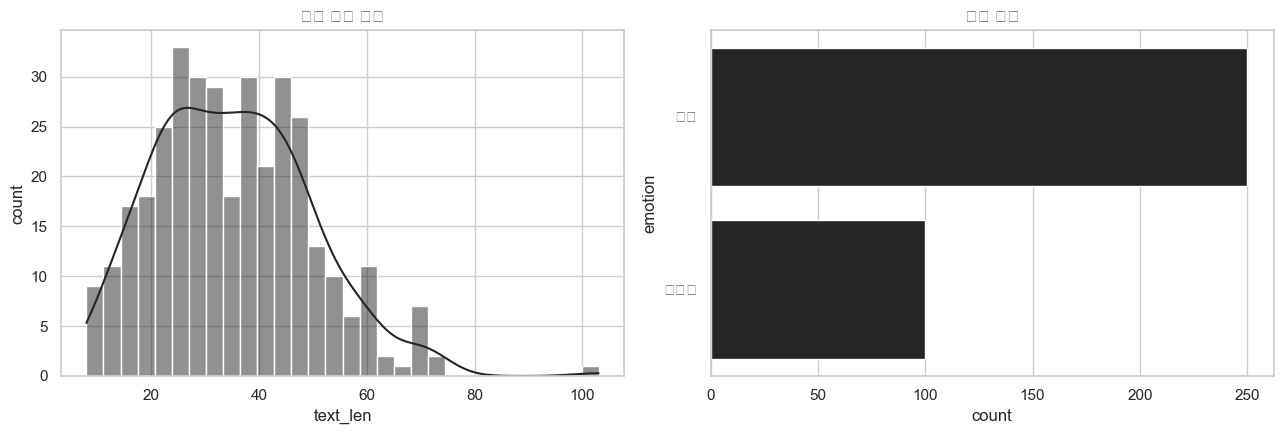

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_sent["text_len"], bins=30, kde=True, color=MAIN_COLOR, ax=axes[0])
axes[0].set_title("문장 길이 분포")
axes[0].set_xlabel("text_len")
axes[0].set_ylabel("count")

top_emotions = df_sent["emotion"].astype(str).value_counts().head(15).index
sns.countplot(
    data=df_sent[df_sent["emotion"].astype(str).isin(top_emotions)],
    y="emotion",
    order=top_emotions,
    color=MAIN_COLOR,
    ax=axes[1],
)
axes[1].set_title("감정 분포")
axes[1].set_xlabel("count")
axes[1].set_ylabel("emotion")

plt.tight_layout()
plt.show()

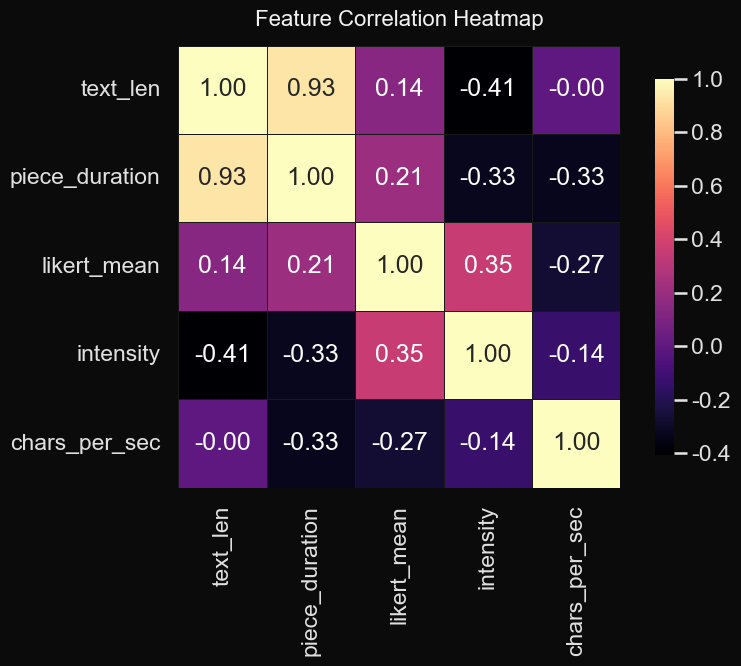

In [7]:
import numpy as np

plt.style.use("dark_background")
sns.set_theme(
    style="dark",
    context="talk",
    rc={
        "axes.facecolor": "#111111",
        "figure.facecolor": "#0B0B0B",
        "axes.edgecolor": "#BBBBBB",
        "grid.color": "#2F2F2F",
        "text.color": "#F2F2F2",
        "axes.labelcolor": "#EAEAEA",
        "xtick.color": "#E0E0E0",
        "ytick.color": "#E0E0E0",
    },
)

plot_df = df_sent.copy()
plot_df["chars_per_sec"] = plot_df["text_len"] / plot_df["piece_duration"].replace(0, np.nan)

num_cols = ["text_len", "piece_duration", "likert_mean", "intensity", "chars_per_sec"]
corr = plot_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.6,
    linecolor="#1A1A1A",
    square=True,
    cbar_kws={"shrink": 0.85},
)
ax.set_title("Feature Correlation Heatmap", pad=14, fontsize=16)
plt.tight_layout()
plt.show()

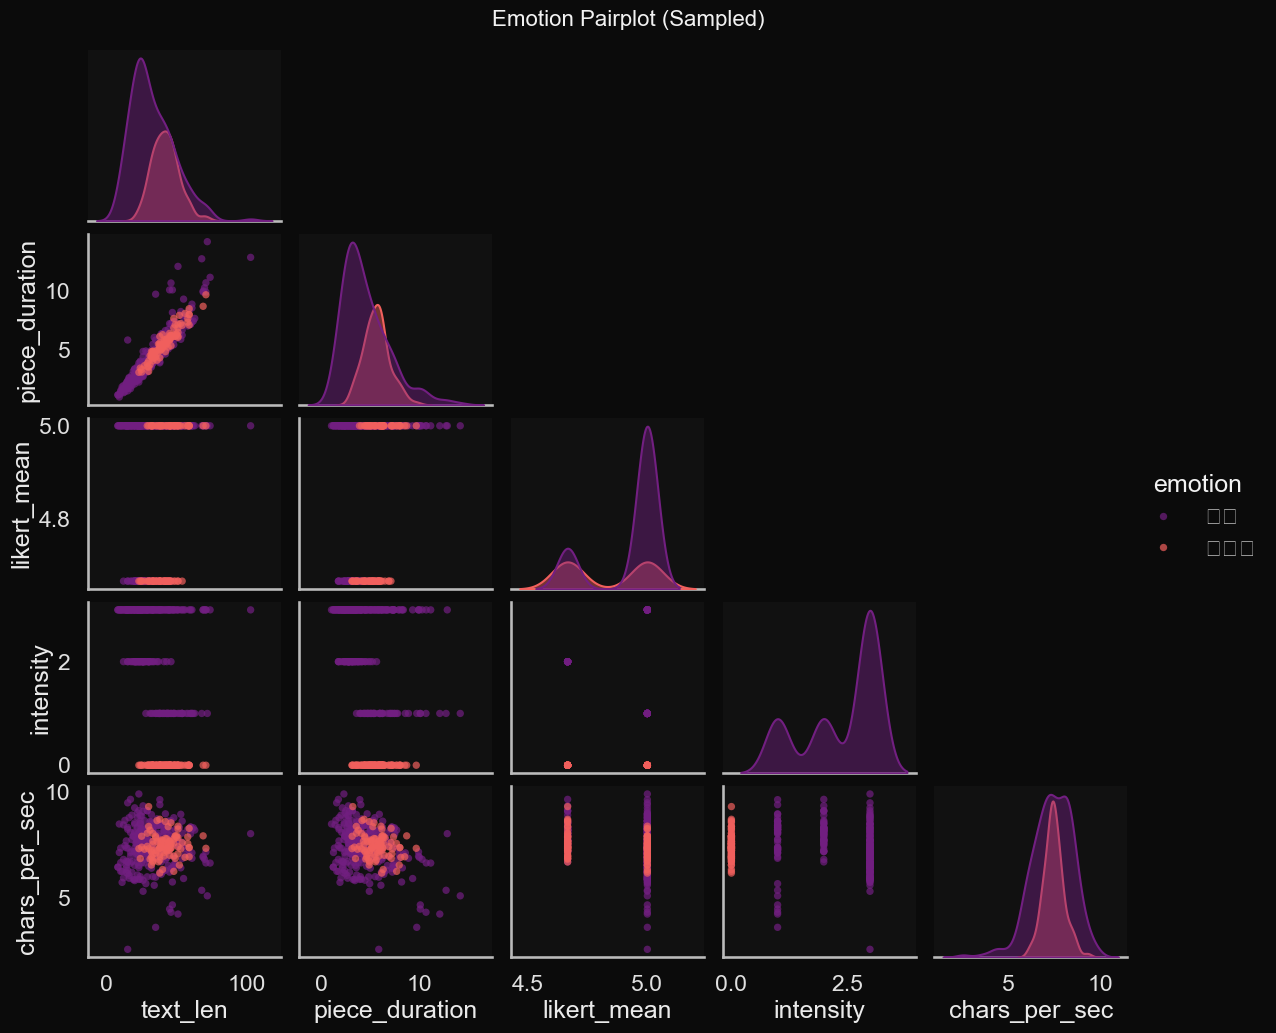

In [8]:
pair_df = plot_df[["emotion"] + num_cols].dropna().copy()
if len(pair_df) > 700:
    pair_df = pair_df.sample(700, random_state=42)

g = sns.pairplot(
    data=pair_df,
    vars=num_cols,
    hue="emotion",
    palette="magma",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.7, "s": 28, "edgecolor": "none"},
    diag_kws={"fill": True, "alpha": 0.45},
)
g.fig.set_size_inches(13, 10)
g.fig.suptitle("Emotion Pairplot (Sampled)", y=1.02, fontsize=16)
plt.show()

/var/folders/_z/lk5nb_w55c7clyq38bbzkzz40000gn/T/ipykernel_13595/537382400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/_z/lk5nb_w55c7clyq38bbzkzz40000gn/T/ipykernel_13595/537382400.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


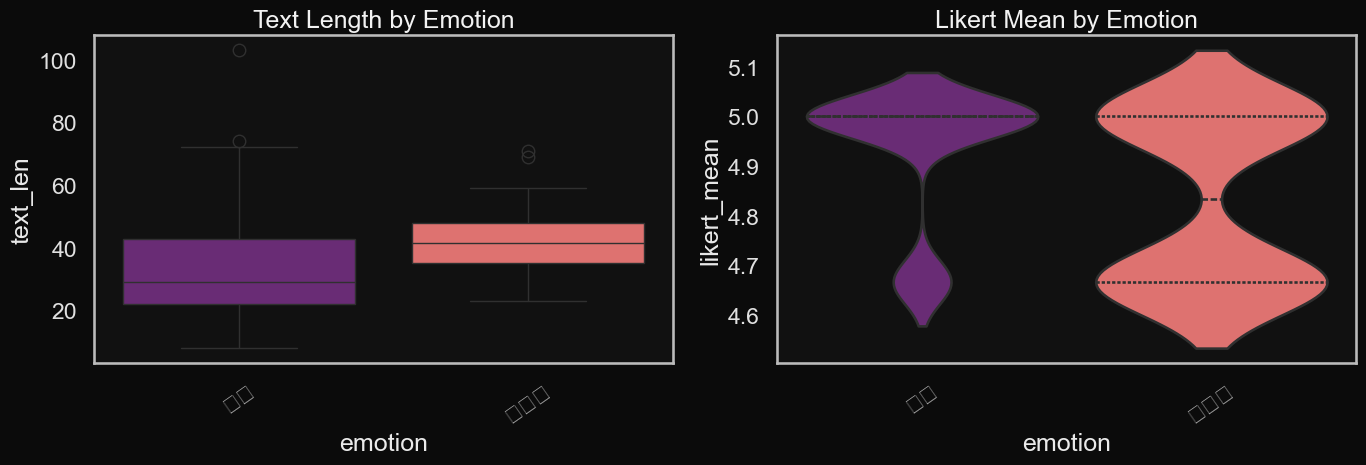

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=plot_df,
    x="emotion",
    y="text_len",
    palette="magma",
    ax=axes[0],
)
axes[0].set_title("Text Length by Emotion")
axes[0].tick_params(axis="x", rotation=35)

sns.violinplot(
    data=plot_df,
    x="emotion",
    y="likert_mean",
    palette="magma",
    inner="quartile",
    ax=axes[1],
)
axes[1].set_title("Likert Mean by Emotion")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()